## Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import scipy
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import xgboost as xgb
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold

import matplotlib.pyplot as plt

import time

import datetime

import pickle
from metrics import get_metrics

from loguru import logger
import geopy
import reverse_geocode
import pycountry_convert as pc
import colorsys

## Global Variables

In [2]:
FEAT_SCALE_TYPE = "linear_scale"    # options: "linear_scale", "standardize"

input_cols= ['b1_min','b1_mean','b1_max','b1_std','b1_median','b1_count',
            'b2_min','b2_mean','b2_max','b2_std','b2_median','b3_min',
            'b3_mean','b3_max','b3_std','b3_median','b4_min','b4_mean',
            'b4_max','b4_std','b4_median','b10_min','b10_mean','b10_max',
            'b10_std','b10_median','b11_min','b11_mean','b11_max','b11_std',
            'b11_median','b12_min','b12_mean','b12_max','b12_std','b12_median',
            'b8a_min','b8a_mean','b8a_max','b8a_std','b8a_median',#'LorS',
            # "lat","lon", 
            # "R.BS", "BG", "N_R", "RG", "bright", "GR",
            # "NR",
            # "BR",
            # "SR",
            # "NG",
            # "SG",
            # "BN",
            # "GN",
            # "RN",
            # "SN",
            # "BS",
            # "GS",
            # "RS",
            # "NS",
            # "R.GN",
            # "R.GB",
            # "R.GS",
            # "R.BN",
            # "R.NS",
            # "G.BR",
            # "G.BN",
            # "G.BS",
            # "G.RN",
            # "G.RB",
            # "G.RS",
            # "B.RG",
            # "B.RN",
            # "B.RS",
            # "B.GN",
            # "B.GS",
            # "B.NS",
            # "N.RG",
            # "N.RB",
            # "N.RS",
            # "N.GB",
            # "N.GS",
            # "N.BS",
            # "GR2",
            # "GN2",
            # "BR_G",
            # "NS_NR",
            # "N_S",
            # "ndvi",
            # "ndwi",
            ]
# input_cols = [
#     "b8a_mean",	"R.BS",	"b12_mean",	"N_R",	"BG",	"b11_mean",	"RG",	"bright",	"GR"
# ]
# input_cols = [
#     "nir",	"R.BS",	"swir2",	"N_R",	"BG",	"swir1",	"RG",	"bright",	"GR",
# ]

median_cols=['b1_median','b2_median','b3_median',\
                 'b4_median','b10_median','b11_median',\
                 'b12_median','b8a_median']

qa_col = 'b1_count'

cloud_cover_col = 'cloud_cover'
cloud_cut_number=50 #eliminate tiles with over 50 percent cloud cover

mgrs_col = 'MGRS'
mgrs_cut_number=0.5 #over 0.5 is 1
    
output_col = 'tss_value'
# output_col = 'value'
output_cols = [output_col]

coords_cols= ['lat','lon']

lors_col=['LorS']

reps=10 #number of repetitions for each model
reps=reps+1 #because of how python does its counting

varnum=len(input_cols)#

In [3]:
# Set random seeds for reproducibility
SEED = 123
np.random.seed(SEED)
random.seed(SEED)

## Data Cleaning/Filtering

In [4]:
""" SKIPPING THIS SINCE JUST LOADING PRE-SPLIT DATA
# PREPROCESSING
df_merged = df_merged[df_merged[cloud_cover_col] <= cloud_cut_number] # Remove tiles with more than 50% cloud cover
df_merged = df_merged[df_merged[mgrs_col] < mgrs_cut_number]  # Remove tiles with mgrs=1
df_merged = df_merged.replace([np.inf, -np.inf], np.nan)    # Change inf values to nan

df_merged = df_merged.dropna(subset=input_cols, how="any", axis=0)  # Remove rows where any feature col is nan
df_merged = df_merged.dropna(subset=output_cols, how="any", axis=0) # Remove rows where output is nan

data_output_array_filtered2 = df_merged[output_col].to_numpy()   # TODO: remove/rename (retained due to previous version)

# Remove low ssc and high reflectance
for col in median_cols:
    df_merged = df_merged[~((df_merged[col] > 1000.0) & (df_merged[output_col] < 2.0))]
# Remove high ssc and low reflectance
for col in median_cols:
    df_merged = df_merged[~((df_merged[col] < 50.0) & (df_merged[output_col] > 500.0))]

# Remove samples with too many (lake) or too few pixels
min_num_pixels = 10
max_num_pixels = 250
df_merged = df_merged[~((df_merged[qa_col] < min_num_pixels) | (df_merged[qa_col] > max_num_pixels))]

data_input = df_merged[input_cols]  # Filter to feature columns
data_output = df_merged[output_col]
data_output = np.log(data_output)   # output in log scale (ln actually)
data_coords = df_merged[coords_cols]
data_input_coords = df_merged[input_cols + coords_cols]
data_input_array = data_input.to_numpy()
data_output_array = data_output.to_numpy()
data_coords_array = data_coords.to_numpy()

data_output_array_filtered3 = data_output_array     # TODO: remove/rename (retained due to previous version)
data_input_array_filtered2 = data_input_array     # TODO: remove/rename (retained due to previous version)
data_coords_array_filtered2 = data_coords_array # TODO: remove/rename (retained due to previous version)
"""

' SKIPPING THIS SINCE JUST LOADING PRE-SPLIT DATA\n# PREPROCESSING\ndf_merged = df_merged[df_merged[cloud_cover_col] <= cloud_cut_number] # Remove tiles with more than 50% cloud cover\ndf_merged = df_merged[df_merged[mgrs_col] < mgrs_cut_number]  # Remove tiles with mgrs=1\ndf_merged = df_merged.replace([np.inf, -np.inf], np.nan)    # Change inf values to nan\n\ndf_merged = df_merged.dropna(subset=input_cols, how="any", axis=0)  # Remove rows where any feature col is nan\ndf_merged = df_merged.dropna(subset=output_cols, how="any", axis=0) # Remove rows where output is nan\n\ndata_output_array_filtered2 = df_merged[output_col].to_numpy()   # TODO: remove/rename (retained due to previous version)\n\n# Remove low ssc and high reflectance\nfor col in median_cols:\n    df_merged = df_merged[~((df_merged[col] > 1000.0) & (df_merged[output_col] < 2.0))]\n# Remove high ssc and low reflectance\nfor col in median_cols:\n    df_merged = df_merged[~((df_merged[col] < 50.0) & (df_merged[output_col]

In [5]:
# df_merged.to_csv("cleaned_data.csv", index=False)  # To be used for integration

## Train/val/test Splits

In [6]:
"""
# TODO: use geographic location as variable in splitting data (i.e., make sure same location doesn't appear in 2 different data splits)

quartiles_1 = np.quantile(data_output_array_filtered3,0.25)    # Rangel NOTE: changed next 3 lines data_output_array_filtered-> data_output_array_filtered3
quartiles_2 = np.quantile(data_output_array_filtered3,0.5)
quartiles_3 = np.quantile(data_output_array_filtered3,0.75)

#run through the data_output array and add classes 
flag_class=np.zeros(len(data_output_array_filtered3))
for i in range(0,len(data_output_array_filtered3)):
    if (data_output_array_filtered3[i]<quartiles_1):
        flag_class[i]=1
    elif (data_output_array_filtered3[i]<quartiles_2):
        flag_class[i]=2
    elif (data_output_array_filtered3[i]<quartiles_3):
        flag_class[i]=3
    else:
        flag_class[i]=4
x_train, x_rest, y_train, y_rest = train_test_split(
    data_input_coords, data_output, train_size=0.5,  shuffle=True, stratify=flag_class, random_state=SEED,
)

#now, select the validation and test 
flag_class=np.zeros(len(y_rest))
for i in range(0,len(y_rest)):
    if (y_rest.values[i]<quartiles_1):
        flag_class[i]=1
    elif (y_rest.values[i]<quartiles_2):
        flag_class[i]=2
    elif (y_rest.values[i]<quartiles_3):
        flag_class[i]=3
    else:
        flag_class[i]=4
x_val, x_test, y_val, y_test = train_test_split(
    x_rest, y_rest, test_size=0.5, train_size=0.5, shuffle=True, stratify=flag_class, random_state=SEED,
)
"""

"\n# TODO: use geographic location as variable in splitting data (i.e., make sure same location doesn't appear in 2 different data splits)\n\nquartiles_1 = np.quantile(data_output_array_filtered3,0.25)    # Rangel NOTE: changed next 3 lines data_output_array_filtered-> data_output_array_filtered3\nquartiles_2 = np.quantile(data_output_array_filtered3,0.5)\nquartiles_3 = np.quantile(data_output_array_filtered3,0.75)\n\n#run through the data_output array and add classes \nflag_class=np.zeros(len(data_output_array_filtered3))\nfor i in range(0,len(data_output_array_filtered3)):\n    if (data_output_array_filtered3[i]<quartiles_1):\n        flag_class[i]=1\n    elif (data_output_array_filtered3[i]<quartiles_2):\n        flag_class[i]=2\n    elif (data_output_array_filtered3[i]<quartiles_3):\n        flag_class[i]=3\n    else:\n        flag_class[i]=4\nx_train, x_rest, y_train, y_rest = train_test_split(\n    data_input_coords, data_output, train_size=0.5,  shuffle=True, stratify=flag_class

In [7]:

def country_to_continent(country_name):
    country_alpha2 = pc.country_name_to_country_alpha2(country_name)
    if country_alpha2 == "VA":
        return "Europe"
    country_continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
    country_continent_name = pc.convert_continent_code_to_continent_name(country_continent_code)
    return country_continent_name

def add_location_info(data_df):
    lats=data_df['lat'].to_list()
    lons=data_df['lon'].to_list()
    coords = list(zip(lats, lons))
    addresses = reverse_geocode.search(coords)

    country_codes = []
    cities = []
    countries = []
    for add in addresses:
        country_codes.append(add["country_code"])
        cities.append(add["city"])
        countries.append(add["country"])
    data_df["country_code"] = country_codes
    data_df["country"] = countries
    data_df["city"] = cities

    continents = []
    for c in countries:
        cont=""
        if c:
            cont = country_to_continent(c)
        continents.append(cont)
    data_df["continent"] = continents

    return data_df

## Adding More Features

In [8]:
EPS = 1e-7
def add_more_feats(data_df):
    # nir	R.BS	swir2	N_R	BG	swir1	RG	bright	GR
    data_df["NR"] = data_df["b8a_mean"]/(data_df["b4_mean"] + EPS)
    data_df["BR"] = data_df["b2_mean"]/(data_df["b4_mean"] + EPS)
    data_df["SR"] = data_df["b11_mean"]/(data_df["b4_mean"] + EPS)  # swir1/red
    data_df["NG"] = data_df["b8a_mean"]/(data_df["b3_mean"] + EPS)  # nir/green
    data_df["SG"] = data_df["b11_mean"]/(data_df["b3_mean"] + EPS)  # swir1/green
    data_df["BN"] = data_df["b2_mean"]/(data_df["b8a_mean"] + EPS)
    data_df["GN"] = data_df["b3_mean"]/(data_df["b8a_mean"] + EPS)
    data_df["RN"] = data_df["b4_mean"]/(data_df["b8a_mean"] + EPS)
    data_df["SN"] = data_df["b11_mean"]/(data_df["b8a_mean"] + EPS)
    data_df["BS"] = data_df["b2_mean"]/(data_df["b11_mean"] + EPS)
    data_df["GS"] = data_df["b3_mean"]/(data_df["b11_mean"] + EPS)
    data_df["RS"] = data_df["b4_mean"]/(data_df["b11_mean"] + EPS)
    data_df["NS"] = data_df["b8a_mean"]/(data_df["b11_mean"] + EPS)

    data_df["R.GN"] = data_df["b4_mean"]/(data_df["b3_mean"] + data_df["b8a_mean"] + EPS)
    data_df["R.GB"] = data_df["b4_mean"]/(data_df["b3_mean"] + data_df["b2_mean"] + EPS)
    data_df["R.GS"] = data_df["b4_mean"]/(data_df["b3_mean"] + data_df["b11_mean"] + EPS)
    data_df["R.BN"] = data_df["b4_mean"]/(data_df["b2_mean"] + data_df["b8a_mean"] + EPS)
    data_df["R.NS"] = data_df["b4_mean"]/(data_df["b8a_mean"] + data_df["b11_mean"] + EPS)

    data_df["G.BR"] = data_df["b3_mean"]/(data_df["b2_mean"] + data_df["b4_mean"] + EPS)
    data_df["G.BN"] = data_df["b3_mean"]/(data_df["b2_mean"] + data_df["b8a_mean"] + EPS)
    data_df["G.BS"] = data_df["b3_mean"]/(data_df["b2_mean"] + data_df["b11_mean"] + EPS)
    data_df["G.RN"] = data_df["b3_mean"]/(data_df["b4_mean"] + data_df["b8a_mean"] + EPS)
    data_df["G.RB"] = data_df["b3_mean"]/(data_df["b4_mean"] + data_df["b2_mean"] + EPS)
    data_df["G.RS"] = data_df["b3_mean"]/(data_df["b4_mean"] + data_df["b11_mean"] + EPS)

    data_df["B.RG"] = data_df["b2_mean"]/(data_df["b4_mean"] + data_df["b3_mean"] + EPS)
    data_df["B.RN"] = data_df["b2_mean"]/(data_df["b4_mean"] + data_df["b8a_mean"] + EPS)
    data_df["B.RS"] = data_df["b2_mean"]/(data_df["b4_mean"] + data_df["b11_mean"] + EPS)
    data_df["B.GN"] = data_df["b2_mean"]/(data_df["b3_mean"] + data_df["b8a_mean"] + EPS)
    data_df["B.GS"] = data_df["b2_mean"]/(data_df["b3_mean"] + data_df["b11_mean"] + EPS)
    data_df["B.NS"] = data_df["b2_mean"]/(data_df["b8a_mean"] + data_df["b11_mean"] + EPS)

    data_df["N.RG"] = data_df["b8a_mean"]/(data_df["b4_mean"] + data_df["b3_mean"] + EPS)
    data_df["N.RB"] = data_df["b8a_mean"]/(data_df["b4_mean"] + data_df["b2_mean"] + EPS)
    data_df["N.RS"] = data_df["b8a_mean"]/(data_df["b4_mean"] + data_df["b11_mean"] + EPS)
    data_df["N.GB"] = data_df["b8a_mean"]/(data_df["b3_mean"] + data_df["b2_mean"] + EPS)
    data_df["N.GS"] = data_df["b8a_mean"]/(data_df["b3_mean"] + data_df["b11_mean"] + EPS)
    data_df["N.BS"] = data_df["b8a_mean"]/(data_df["b2_mean"] + data_df["b11_mean"] + EPS)

    data_df["GR2"] = (data_df["b3_mean"] + data_df["b4_mean"])/2
    data_df["GN2"] = (data_df["b3_mean"] + data_df["b8a_mean"])/2

    data_df["BR_G"] = (data_df["b2_mean"] - data_df["b4_mean"])/(data_df["b3_mean"] + EPS)
    data_df["NS_NR"] = (data_df["b8a_mean"] - data_df["b11_mean"])/(data_df["b4_mean"] - data_df["b8a_mean"] + EPS)
    data_df["N_S"] = (data_df["b8a_mean"] - data_df["b11_mean"])
    data_df["ndvi"] = (data_df["b8a_mean"] - data_df["b4_mean"])/(data_df["b8a_mean"] + data_df["b4_mean"]+EPS)
    data_df["ndwi"] = (data_df["b3_mean"] - data_df["b11_mean"])/(data_df["b3_mean"] + data_df["b11_mean"]+EPS)

    data_df["R.BS"] = data_df["b4_mean"]/(data_df["b2_mean"]+data_df["b11_mean"]+EPS) # red/(blue+swir1); red=band4, blue=band2, green=band3
    data_df["N_R"] =  data_df["b8a_mean"]-data_df["b4_mean"]  # nir - red
    data_df["BG"] =  data_df["b2_mean"]/(data_df["b3_mean"]+EPS) # blue/green
    data_df["RG"] =  data_df["b4_mean"]/(data_df["b3_mean"]+EPS)# red/green
    hsv_arr = [
        colorsys.rgb_to_hsv(r/255.,g/255.,b/255.)
        for _, (r,g,b) in data_df[['b4_mean','b3_mean','b2_mean']].iterrows()
    ]
    data_df["bright"] = [v for h,s,v in hsv_arr]
    data_df["GR"] =  data_df["b3_mean"]/(data_df["b4_mean"]+EPS)# red/green

    return data_df

In [9]:
# LOAD SPLITS BASED ON multitask model splits
# train_ssc = pd.read_csv("../data/orig_feats/train_ssc.csv")
# val_ssc = pd.read_csv("../data/orig_feats/val_ssc.csv")
# test_ssc = pd.read_csv("../data/orig_feats/test_ssc.csv")

train_ssc_orig = pd.read_csv("../data/new_feats_v3/train.csv")
val_ssc_orig = pd.read_csv("../data/new_feats_v3/val.csv")
# train_ssc_orig = pd.concat([train_ssc_orig, val_ssc_orig])
test_ssc_orig = pd.read_csv("../data/new_feats_v3/test.csv")
train_ssc_orig = add_location_info(train_ssc_orig)
val_ssc_orig = add_location_info(val_ssc_orig)
test_ssc_orig = add_location_info(test_ssc_orig)

train_ssc_orig = train_ssc_orig[train_ssc_orig["continent"]=="North America"]
val_ssc_orig = val_ssc_orig[val_ssc_orig["continent"]=="North America"]
test_ssc_orig = test_ssc_orig[test_ssc_orig["continent"]=="North America"]
# train_ssc_orig = train_ssc_orig[train_ssc_orig["LorS"]==1]
# val_ssc_orig = val_ssc_orig[val_ssc_orig["LorS"]==1]
# test_ssc_orig = test_ssc_orig[test_ssc_orig["LorS"]==1]

# Add more features
train_ssc_orig = add_more_feats(train_ssc_orig)
val_ssc_orig = add_more_feats(val_ssc_orig)
test_ssc_orig = add_more_feats(test_ssc_orig)


# train_ssc_orig = pd.read_csv("old_usa_data/train_clean_v1.csv")
# train_ssc_orig["value"] = np.exp(train_ssc_orig["value"])
# val_ssc_orig = pd.read_csv("old_usa_data/validation_v1.csv")
# test_ssc_orig = pd.read_csv("old_usa_data/validation_v1.csv")

train_ssc_orig = train_ssc_orig.dropna(subset = input_cols+output_cols, how="any")
val_ssc_orig = val_ssc_orig.dropna(subset = input_cols+output_cols, how="any")
test_ssc_orig = test_ssc_orig.dropna(subset = input_cols+output_cols, how="any")
train_ssc = train_ssc_orig[input_cols+output_cols]
val_ssc = val_ssc_orig[input_cols+output_cols]
test_ssc = test_ssc_orig[input_cols+output_cols]


x_train = train_ssc[input_cols]
x_val = val_ssc[input_cols]
x_test = test_ssc[input_cols]


y_train = np.log(train_ssc[output_col])
y_val = np.log(val_ssc[output_col])
y_test = np.log(test_ssc[output_col])

/home/rdaroya_umass_edu/miniconda3/envs/ann-ssc/lib/python3.9/site-packages/pycountry/db.py:51: UserWarning: Country's official_name not found. Country name provided instead.
  warnings.warn(warning_message, UserWarning)
/home/rdaroya_umass_edu/miniconda3/envs/ann-ssc/lib/python3.9/site-packages/pycountry/db.py:51: UserWarning: Country's common_name not found. Country name provided instead.
  warnings.warn(warning_message, UserWarning)


## Feature Preprocessing/Normalization

### Option 1: Linear Scaling

In [10]:
if FEAT_SCALE_TYPE == "linear_scale":    # options: "linear_scale", "standardize"
    logger.debug("Normalizing features and labels")

    y_train, y_val, y_test = (
        y_train.values.reshape((-1,)),
        y_val.values.reshape((-1,)),
        y_test.values.reshape((-1,)),
    )
    # coords_train = x_train[coords_cols].to_numpy()
    # coords_val = x_val[coords_cols].to_numpy()
    # coords_test = x_test[coords_cols].to_numpy()
    x_train = x_train[input_cols].to_numpy()
    x_val = x_val[input_cols].to_numpy()
    x_test = x_test[input_cols].to_numpy()

    logger.debug(f"x_train: {x_train.shape}, max: {np.max(x_train)} min: {np.min(x_train)}. y_train: {y_train.shape}, max: {np.max(y_train)} min: {np.min(y_train)}. ")
    logger.debug(f"x_val: {x_val.shape}, max: {np.max(x_val)} min: {np.min(x_val)}. y_val: {y_val.shape}, max: {np.max(y_val)} min: {np.min(y_val)}. ")
    logger.debug(f"x_test: {x_test.shape}, max: {np.max(x_test)} min: {np.min(x_test)}. y_test: {y_test.shape}, max: {np.max(y_test)} min: {np.min(y_test)}. ")

    # Normalize features and labels based on the training data
    logger.debug("Apply linear scaling to labels and features")
    y_train_max, y_train_min = np.max(y_train), np.min(y_train)
    x_train_max, x_train_min = np.max(x_train, axis=0), np.min(x_train, axis=0)

    x_train_norm = (x_train-x_train_min)/(x_train_max - x_train_min)
    x_val_norm = (x_val-x_train_min)/(x_train_max - x_train_min)
    x_test_norm = (x_test-x_train_min)/(x_train_max - x_train_min)

    y_train_norm = (y_train - y_train_min)/(y_train_max-y_train_min)    # NOTE: need to un-normalize predictions for validation and test sets


2024-02-12 16:54:25.483 | DEBUG    | __main__:<module>:2 - Normalizing features and labels
2024-02-12 16:54:25.498 | DEBUG    | __main__:<module>:16 - x_train: (12974, 41), max: 257569.0 min: -2739.0. y_train: (12974,), max: 6.363028103540465 min: -4.605170185988091. 
2024-02-12 16:54:25.499 | DEBUG    | __main__:<module>:17 - x_val: (1837, 41), max: 233910.0 min: -2478.0. y_val: (1837,), max: 6.075346031088684 min: -0.916290731874155. 
2024-02-12 16:54:25.503 | DEBUG    | __main__:<module>:18 - x_test: (1732, 41), max: 206527.0 min: -2265.0. y_test: (1732,), max: 6.583409222158765 min: -4.605170185988091. 
2024-02-12 16:54:25.505 | DEBUG    | __main__:<module>:21 - Apply linear scaling to labels and features


In [11]:
np.sum(x_val_norm), np.sum(x_test_norm)

(20092.456980448875, 18771.554882631637)

In [12]:
train_ssc[input_cols]

,b1_min,b1_mean,b1_max,b1_std,b1_median,b1_count,b2_min,b2_mean,b2_max,b2_std,...,b12_min,b12_mean,b12_max,b12_std,b12_median,b8a_min,b8a_mean,b8a_max,b8a_std,b8a_median
4,-151.0,106.783595,1201.0,163.922907,13.0,29990,-50.0,189.042841,1415.0,157.275611,...,-215.0,81.488076,3053.0,234.614624,18.0,-252.0,199.872480,4261.0,356.613125,82.0
5,-358.0,525.208034,1953.0,130.374024,531.0,27531,-271.0,706.696484,2247.0,153.867947,...,-211.0,139.353018,3613.0,388.237402,15.0,-322.0,274.570131,3839.0,480.048520,95.0
6,-1209.0,282.053337,1634.0,73.949961,276.0,27690,-942.0,279.439874,1747.0,66.692186,...,-173.0,13.951358,2133.0,95.413535,4.0,-553.0,-13.329626,3242.0,136.418071,-19.0
7,-368.0,89.277699,1484.0,132.225663,21.0,32478,-190.0,146.547144,1673.0,141.140945,...,-202.0,102.992341,3165.0,269.457043,27.0,-307.0,132.206864,3469.0,351.978648,11.0
8,-328.0,115.791751,1565.0,176.638560,56.0,30003,-86.0,250.488076,1777.0,169.944702,...,-185.0,144.692422,2974.0,252.500519,83.0,-312.0,213.592101,4927.0,398.732756,102.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18116,-1610.0,185.766313,1608.0,58.687576,184.0,110710,-1246.0,238.523602,1761.0,70.012224,...,-262.0,14.123293,1850.0,37.006781,12.0,-466.0,-9.206066,3639.0,63.461317,-10.0
18117,-1862.0,76.505648,1968.0,187.728336,105.0,60079,-1231.0,134.311873,2306.0,147.438126,...,-239.0,102.849538,3988.0,134.468195,61.0,-421.0,62.569914,4491.0,171.581559,7.0
18118,-24.0,226.470778,836.0,63.227178,224.0,14852,-3.0,236.895435,1287.0,75.819195,...,6.0,135.156747,2911.0,203.764171,70.0,30.0,438.008618,3949.0,509.660473,266.0
18119,-367.0,228.366000,1438.0,132.045765,232.0,11684,-169.0,315.311869,1640.0,136.818058,...,-139.0,389.820592,2621.0,444.676188,165.0,-328.0,486.457585,3248.0,527.122294,230.0


### Option 2: Standardize

In [13]:
if FEAT_SCALE_TYPE == "standardize":
    logger.debug("Standardizing features and labels")

    y_train, y_val, y_test = (
        y_train.values.reshape((-1,)),
        y_val.values.reshape((-1,)),
        y_test.values.reshape((-1,)),
    )

    mean_var_feats = {}
    x_train_norm = pd.DataFrame()
    x_val_norm = pd.DataFrame()
    x_test_norm = pd.DataFrame()
    for col in input_cols:
        if col in lors_col: # categorical column
            x_train_norm[col] = x_train[col]
            x_val_norm[col] = x_val[col]
            x_test_norm[col] = x_test[col]
            continue
        mu = np.mean(x_train[col])
        stddev = np.var(x_train[col])**0.5
        x_train_norm[col] = (x_train[col] - mu)/stddev
        x_val_norm[col] = (x_val[col] - mu)/stddev
        x_test_norm[col] = (x_test[col] - mu)/stddev

        mean_var_feats[col] = {"mu": mu, "stddev": stddev,}

    label_mu, label_stddev = np.mean(y_train), np.var(y_train)**0.5
    y_train_norm = (y_train - label_mu)/label_stddev

    x_train_norm = x_train_norm.to_numpy()
    x_val_norm = x_val_norm.to_numpy()
    x_test_norm = x_test_norm.to_numpy()

In [14]:
FEAT_SCALE_TYPE

'linear_scale'

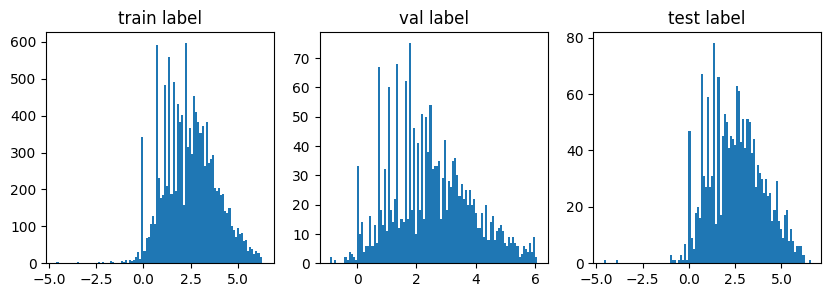

In [15]:
fig=plt.figure(figsize=(10,3))
n_rows,n_cols = 1,3

ax = fig.add_subplot(n_rows,n_cols,1)
ax.hist(y_train, bins=100)
plt.title("train label")


ax = fig.add_subplot(n_rows,n_cols,2)
ax.hist(y_val, bins=100)
plt.title("val label")


ax = fig.add_subplot(n_rows,n_cols,3)
ax.hist(y_test, bins=100)
plt.title("test label")

plt.show()

In [16]:
x_train.shape, x_val.shape, x_test.shape

((12974, 41), (1837, 41), (1732, 41))

In [17]:
x_train_norm[:,-1]

array([0.18967791, 0.19212658, 0.17065361, ..., 0.22433603, 0.2175551 ,
       0.26521002])

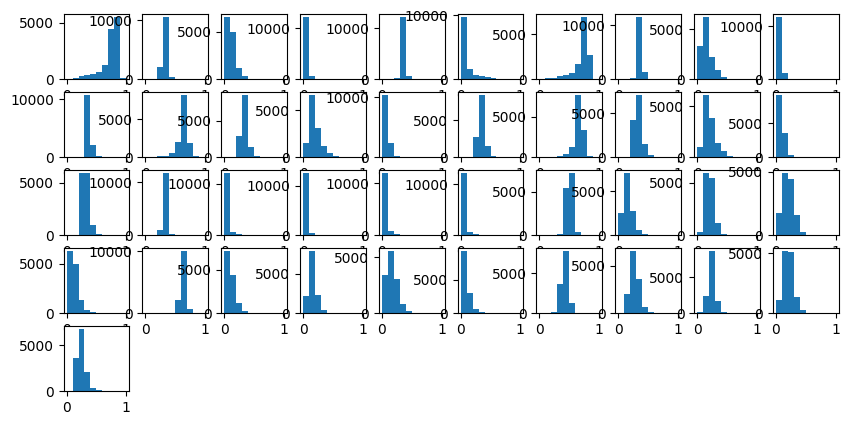

In [18]:
# plt.hist(y_train_norm)

n_rows,n_cols = 12,10
fig=plt.figure(figsize=(n_cols,n_rows))
for i, var_name in enumerate(input_cols):
    # print(var_name)
    ax = fig.add_subplot(n_rows,n_cols,i+1)
    ax.hist(x_train_norm[:,i], bins=10)
    # plt.title(var_name)
# plt.tight_layout()
plt.show()

# input_cols= ['b1_min','b1_mean','b1_max','b1_std','b1_median','b1_count',
#             'b2_min','b2_mean','b2_max','b2_std','b2_median','b3_min',
#             'b3_mean','b3_max','b3_std','b3_median','b4_min','b4_mean',
#             'b4_max','b4_std','b4_median','b10_min','b10_mean','b10_max',
#             'b10_std','b10_median','b11_min','b11_mean','b11_max','b11_std',
#             'b11_median','b12_min','b12_mean','b12_max','b12_std','b12_median',
#             'b8a_min','b8a_mean','b8a_max','b8a_std','b8a_median','LorS'
#             ]

## Train Model

In [19]:
params = {
    "n_estimators": 100,
    "lambda": 1,
    "alpha": 0.01,
    "eta": 0.3,
    "objective": "reg:squarederror",

    # "n_estimators": 1000,
    # "lambda": 1,    # L2 regularization
    # "alpha": 0.01,  # L1 regularization
    # "eta": 0.01,
    # "objective": "reg:squarederror",    #reg:absoluteerror
    
#     # 'max_depth': 5,
#     # "booster": "gblinear",
}
# params = {"n_estimators": 1000, 'alpha': 0.001, 'eta': 0.01, 'lambda': 3, 'max_depth': 10, 'objective': 'reg:squarederror'}
# params = {"n_estimators": 1000, 'alpha': 0.001, 'eta': 0.01, 'lambda': 3, 'max_depth': 5, 'objective': 'reg:squarederror'}
# params = {'alpha': 0.01, 'eta': 0.05, 'lambda': 3, 'max_depth': 10, 'objective': 'reg:squarederror', "min_child_weight": 5}

params = {'alpha': 0.001, 'eta': 0.05, 'lambda': 3, 'max_depth': 10, 'objective': 'reg:squarederror'}

xgb_reg = xgb.XGBRegressor(**params, seed=22)
xgb_reg.fit(x_train_norm,y_train_norm)
model = xgb_reg

In [20]:
# params={ 
#     'max_depth': 7,
#     'n_estimators': 500,
#     'criterion': 'squared_error',
#     'max_features': 'sqrt',
#     # 'min_samples_split': 3,
#     # 'min_samples_leaf': 23,
#     # 'bootstrap': True,
#     'min_impurity_decrease': 0.02}
# model = RandomForestRegressor(
#     **params,
# )
# model.fit(x_train_norm,y_train_norm)


In [21]:
# model = LinearRegression()
# model.fit(x_train_norm,y_train_norm)

In [22]:
# param = {"batch_size":512, 'activation': 'tanh', 'alpha': 0.001, 'learning_rate': 'constant', 'learning_rate_init': 0.01, 'solver': 'lbfgs'}

# model = MLPRegressor(
#     **param,
# )
# # x = x.values
# model.fit(x_train_norm,y_train_norm)

## Evaluate Model

In [23]:
FEAT_SCALE_TYPE, y_train_max, y_train_min

('linear_scale', 6.363028103540465, -4.605170185988091)

In [24]:
train_pred = model.predict(x_train_norm)
if FEAT_SCALE_TYPE == "standardize":
    train_pred = (train_pred*label_stddev)+label_mu
elif FEAT_SCALE_TYPE == "linear_scale":
    train_pred = (train_pred*(y_train_max-y_train_min)) + y_train_min
train_pred = np.exp(train_pred)
train_gt = np.exp(y_train)
train_metrics = get_metrics(train_gt, train_pred)
train_metrics["corr_coeff"] = np.corrcoef(train_gt, train_pred)[0][1]

val_pred = model.predict(x_val_norm)
if FEAT_SCALE_TYPE == "standardize":
    val_pred = (val_pred*label_stddev)+label_mu
elif FEAT_SCALE_TYPE == "linear_scale":
    val_pred = (val_pred*(y_train_max-y_train_min)) + y_train_min
val_pred = np.exp(val_pred)
val_gt = np.exp(y_val)
val_metrics = get_metrics(val_gt, val_pred)
val_metrics["corr_coeff"] = np.corrcoef(val_gt, val_pred)[0][1]

test_pred = model.predict(x_test_norm)
if FEAT_SCALE_TYPE == "standardize":
    test_pred = (test_pred*label_stddev)+label_mu
elif FEAT_SCALE_TYPE == "linear_scale":
    test_pred = (test_pred*(y_train_max-y_train_min)) + y_train_min
test_pred = np.exp(test_pred)
test_gt = np.exp(y_test)
test_metrics = get_metrics(test_gt, test_pred)
test_metrics["corr_coeff"] = np.corrcoef(test_gt, test_pred)[0][1]
abs_err = np.abs(test_pred-test_gt)
E90=np.quantile(abs_err,0.9)
E95=np.quantile(abs_err,0.95)
print("TEST", E90, E95)

print(f"TRAIN: {train_metrics}")
# print(f"VAL: {val_metrics}")
print(f"TEST: {test_metrics}")

TEST 70.16959018707279 127.73793368339506
TRAIN: {'rmse': 33.28727218857293, 'mae': 11.235454650880932, 'mape': 0.3933230408913511, 'r2': 0.6465000339143092, 'bias': 9.177994750717156, 'pct_bias': -0.1276287595929533, 'smape': 0.337416460330574, 'corr_coeff': 0.9006394901400653}
TEST: {'rmse': 63.59679830279297, 'mae': 26.88876473751474, 'mape': 3.186493629068651, 'r2': 0.0935086744919803, 'bias': 20.038990315263717, 'pct_bias': -2.6446684040710906, 'smape': 0.755298884270616, 'corr_coeff': 0.4916885668356748}


In [25]:
np.median(np.abs(train_pred-train_gt)), np.median(np.abs(val_pred-val_gt)), np.median(np.abs(test_pred-test_gt))

(2.1392204761505145, 6.555569648742676, 6.7174963960634075)

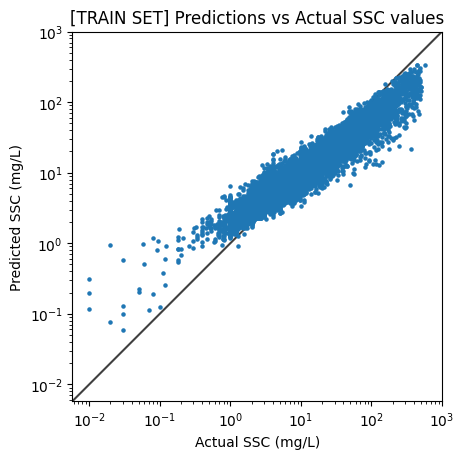

In [26]:
ax = plt.gca()
plt.scatter(train_gt, train_pred, s=5)
plt.ylabel("Predicted SSC (mg/L)")
plt.xlabel("Actual SSC (mg/L)")
plt.title("[TRAIN SET] Predictions vs Actual SSC values")
ax.set_xscale("log")
ax.set_yscale("log")
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against each other
ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.show()

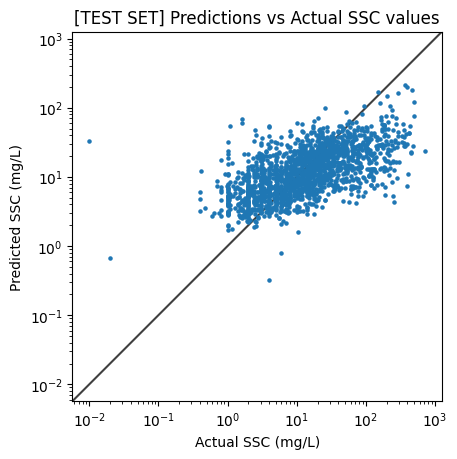

In [27]:
ax = plt.gca()
plt.scatter(test_gt, test_pred, s=5)
plt.ylabel("Predicted SSC (mg/L)")
plt.xlabel("Actual SSC (mg/L)")
plt.title("[TEST SET] Predictions vs Actual SSC values")
ax.set_xscale("log")
ax.set_yscale("log")
lims = [
    np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
    np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
]
# now plot both limits against each other
ax.plot(lims, lims, 'k-', alpha=0.75, zorder=0)
ax.set_aspect('equal')
ax.set_xlim(lims)
ax.set_ylim(lims)
plt.show()

In [28]:
train_ssc_orig["pred"] = train_pred
val_ssc_orig["pred"] = val_pred
test_ssc_orig["pred"] = test_pred
train_ssc_orig["pred_log"] = np.log(train_pred)
val_ssc_orig["pred_log"] = np.log(val_pred)
test_ssc_orig["pred_log"] = np.log(test_pred)
train_ssc_orig["abs_error"] = np.abs(train_gt-train_pred)
val_ssc_orig["abs_error"] = np.abs(val_gt-val_pred)
test_ssc_orig["abs_error"] = np.abs(test_gt-test_pred)

train_ssc_orig["split"] = "train"
val_ssc_orig["split"] = "val"
test_ssc_orig["split"] = "test"

all_preds_df = pd.concat([train_ssc_orig, val_ssc_orig, test_ssc_orig])
all_preds_df["tss_value_log"] = np.log(all_preds_df["tss_value"])
# all_preds_df.to_csv("xgb_preds.csv", index=False)

In [29]:
"""
BEFORE
TEST 51.48562343120572 99.47431898117046
TRAIN: {'rmse': 31.068997928682535, 'mae': 10.688960703698806, 'mape': 0.4785293450546834, 'r2': 0.6373276976194471, 'bias': 8.258423009071176, 'pct_bias': -0.18084357313585175, 'smape': 0.38456941184194404, 'corr_coeff': 0.8911120689145697}
VAL: {'rmse': 48.90863814426789, 'mae': 20.225944919882135, 'mape': 2.070346900596385, 'r2': 0.22807328827784856, 'bias': 13.13580596182462, 'pct_bias': -1.583473847598621, 'smape': 0.7044934350506163, 'corr_coeff': 0.5856885831392995}
TEST: {'rmse': 53.952643557495, 'mae': 21.682631825352082, 'mape': 2.321835357006798, 'r2': 0.17663416344381833, 'bias': 15.117847059635015, 'pct_bias': -1.8129538938682839, 'smape': 0.7001497321697082, 'corr_coeff': 0.55323701874333}
median: (2.4162282180786114, 5.694640874862672, 5.857267409831523)

AFTER (v3)
TEST 55.807850646972696 108.56156616210927
TRAIN: {'rmse': 32.575088899258645, 'mae': 11.003837678374419, 'mape': 0.4806465529440974, 'r2': 0.6008995760003357, 'bias': 8.7820204182936, 'pct_bias': -0.1828734696685357, 'smape': 0.3872290671532733, 'corr_coeff': 0.8750072179795524}
VAL: {'rmse': 50.54419502718347, 'mae': 20.74755109185341, 'mape': 1.966446760955615, 'r2': 0.1807294114267728, 'bias': 13.83987380594198, 'pct_bias': -1.4891767686256876, 'smape': 0.7069334261208774, 'corr_coeff': 0.5585266252225237}
TEST: {'rmse': 55.16592240759148, 'mae': 22.200770829163428, 'mape': 2.787343038921474, 'r2': 0.14257967800932336, 'bias': 16.012467857712146, 'pct_bias': -2.2740914897971716, 'smape': 0.7110897155233874, 'corr_coeff': 0.5268079070531886}
median: (2.389042854309082, 6.042709179685162, 5.923256158828735)

AFTER
TEST 57.35826780319203 113.32419495582543
TRAIN: {'rmse': 37.6643188105519, 'mae': 12.928463157282795, 'mape': 0.5968121299056399, 'r2': 0.4670086858420661, 'bias': 10.389697543624477, 'pct_bias': -0.26963820850680226, 'smape': 0.4378820579081715, 'corr_coeff': 0.8237922861477024}
VAL: {'rmse': 53.40989274441661, 'mae': 21.87217438603291, 'mape': 1.867321674208809, 'r2': 0.07944796806159848, 'bias': 15.190241948814183, 'pct_bias': -1.3602014053978513, 'smape': 0.752460818728174, 'corr_coeff': 0.4453684367653434}
TEST: {'rmse': 58.339124777923665, 'mae': 23.67782731239133, 'mape': 2.7860913156528104, 'r2': 0.037308352182170545, 'bias': 17.235777547346807, 'pct_bias': -2.243729457026637, 'smape': 0.7645165526199075, 'corr_coeff': 0.40150907990935353}
median: (2.7826318740844727, 6.303797006607052, 6.64225339889526)


v2
TEST 56.26689634323113 113.31696662902819
TRAIN: {'rmse': 37.71671149753026, 'mae': 12.93372457665889, 'mape': 0.5900428174780844, 'r2': 0.4655248268317951, 'bias': 10.419036264192291, 'pct_bias': -0.26357709385861117, 'smape': 0.43642931891639086, 'corr_coeff': 0.8313395015001807}
VAL: {'rmse': 53.12594475462236, 'mae': 21.738055950344602, 'mape': 2.063132073393603, 'r2': 0.0892099826433117, 'bias': 15.268458526511598, 'pct_bias': -1.559753074688291, 'smape': 0.748346181993687, 'corr_coeff': 0.48055141052952954}
TEST: {'rmse': 58.324232148196806, 'mae': 23.529816952143136, 'mape': 3.0349032733032426, 'r2': 0.03779979528670929, 'bias': 17.34475323623967, 'pct_bias': -2.4988726356193847, 'smape': 0.7585419475953714, 'corr_coeff': 0.4142086527821604}
median: (2.7703628540039062, 6.4704930782318115, 6.46993808746338)

"""

"\nBEFORE\nTEST 51.48562343120572 99.47431898117046\nTRAIN: {'rmse': 31.068997928682535, 'mae': 10.688960703698806, 'mape': 0.4785293450546834, 'r2': 0.6373276976194471, 'bias': 8.258423009071176, 'pct_bias': -0.18084357313585175, 'smape': 0.38456941184194404, 'corr_coeff': 0.8911120689145697}\nVAL: {'rmse': 48.90863814426789, 'mae': 20.225944919882135, 'mape': 2.070346900596385, 'r2': 0.22807328827784856, 'bias': 13.13580596182462, 'pct_bias': -1.583473847598621, 'smape': 0.7044934350506163, 'corr_coeff': 0.5856885831392995}\nTEST: {'rmse': 53.952643557495, 'mae': 21.682631825352082, 'mape': 2.321835357006798, 'r2': 0.17663416344381833, 'bias': 15.117847059635015, 'pct_bias': -1.8129538938682839, 'smape': 0.7001497321697082, 'corr_coeff': 0.55323701874333}\nmedian: (2.4162282180786114, 5.694640874862672, 5.857267409831523)\n\nAFTER (v3)\nTEST 55.807850646972696 108.56156616210927\nTRAIN: {'rmse': 32.575088899258645, 'mae': 11.003837678374419, 'mape': 0.4806465529440974, 'r2': 0.600899